# Inverse mixed PINN for a 2D compressible Neo-Hookean solid: single network

The reference problem, true $E=1$, true $\nu=0.3$, manufactured displacement, exact boundary values, body force, and point sampling are identical to the displacement-only inverse notebook. Here, the PINN predicts both displacement $\mathbf u_\theta$ and all four components of the first Piola--Kirchhoff stress $\mathbf P_\theta$ directly. Predicted stress is not reconstructed from displacement for equilibrium, plots, or test metrics. A constitutive residual connects the two predictions using trainable $E_\theta$ and $\nu_\theta$.

Displacement and first Piola stress observations at the same random locations are mandatory. Both use the same exact/noisy switch; their noise realizations are independent. The PDE weight, optimizer settings, collocation points, and counts retain their values from the attached notebook.


## 1. Imports


In [1]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = Path("imgs")
OUTPUT_DIR.mkdir(exist_ok=True)


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Settings

The physical problem, five-hidden-layer displacement network, Adam/L-BFGS training, PDE loss weight, and validation rule are unchanged. Only the supervised data sets use fixed master pools: increasing a train, validation, or test data count keeps the earlier coordinates and noisy observations in that split.

`DATA_LOCATION_MODE = "whole_domain"` preserves the original random data locations. `"near_boundary"` draws random interior data only within `BOUNDARY_BAND * L` of an edge. PDE train, validation, and test points are freshly constructed uniform shifted Cartesian grids for the chosen `N_SIDE_PDE_*`. Boundary points use the original `torch.linspace` rule.

The mixed formulation adds the weight `CONSTITUTIVE_WEIGHT = 1.0` for its required constitutive residual and `STRESS_DATA_WEIGHT = 1.0` for observed stress. Both observation types use the same data coordinates and the same exact/noisy mode. This version uses single network for displacement and stress.


In [2]:
USE_DATA = True
DATA_MODE = "noisy"
NOISE_RELATIVE_STD = 0.02
assert DATA_MODE in {"exact", "noisy"}

L = 1.0
E_TRUE = 1.0
POISSON_TRUE = 0.3
MU_TRUE = E_TRUE / (2.0 * (1.0 + POISSON_TRUE))
LAME_LAMBDA_TRUE = (
    E_TRUE * POISSON_TRUE
    / ((1.0 + POISSON_TRUE) * (1.0 - 2.0 * POISSON_TRUE))
)

E_INITIAL = 2.0
POISSON_INITIAL = 0.01

N_SIDE_PDE_TRAIN = 50
N_SIDE_PDE_VALIDATION = 12
N_SIDE_PDE_TEST = 12
PDE_BATCH_SIZE = 64
N_BOUNDARY_PER_EDGE = 40

N_DATA_TRAIN = 30
N_DATA_VALIDATION = 10
N_DATA_TEST = 10
MAX_N_DATA_TRAIN = 1000
MAX_N_DATA_VALIDATION = 400
MAX_N_DATA_TEST = 400
DATA_LOCATION_MODE = "whole_domain"  # "whole_domain" or "near_boundary"
BOUNDARY_BAND = 0.03
assert DATA_LOCATION_MODE in {"whole_domain", "near_boundary"}
assert 0.0 < BOUNDARY_BAND < 0.5

EPOCHS = 2000
LBFGS_EPOCHS = 100
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
LR = 1e-3
SEED = 42
WEIGHT = 1e-0
CONSTITUTIVE_WEIGHT = 1.0
STRESS_DATA_WEIGHT = 1.0

assert 1 <= N_DATA_TRAIN <= MAX_N_DATA_TRAIN
assert 1 <= N_DATA_VALIDATION <= MAX_N_DATA_VALIDATION
assert 1 <= N_DATA_TEST <= MAX_N_DATA_TEST
torch.manual_seed(SEED)
print(f"True Young's modulus: {E_TRUE:.1f}")
print(f"True Poisson ratio: {POISSON_TRUE:.3f}")
print(f"True Lamé lambda: {LAME_LAMBDA_TRUE:.6f}")
print(f"True shear modulus mu: {MU_TRUE:.6f}")
print(f"Initial Young's modulus estimate: {E_INITIAL:.1f}")
print(f"Initial Poisson-ratio estimate: {POISSON_INITIAL:.3f}")
print(f"Displacement data mode: {DATA_MODE}")
if DATA_MODE == "noisy":
    print(f"Relative noise standard deviation: {NOISE_RELATIVE_STD:.1%}")


True Young's modulus: 1.0
True Poisson ratio: 0.300
True Lamé lambda: 0.576923
True shear modulus mu: 0.384615
Initial Young's modulus estimate: 2.0
Initial Poisson-ratio estimate: 0.010
Displacement data mode: noisy
Relative noise standard deviation: 2.0%


## 3. Exact solution, boundary conditions, and manufactured body force

The exact displacement is

$$
\mathbf u(X,Y)=
\begin{bmatrix}
0.1(X^2+Y^2)\\
0.05Y^2
\end{bmatrix}.
$$

The deformation gradient is

$$
\mathbf F(X,Y)=
\begin{bmatrix}
1+0.2X & 0.2Y\\
0 & 1+0.1Y
\end{bmatrix},
\qquad
J=(1+0.2X)(1+0.1Y)>0.
$$

Dirichlet conditions are prescribed on the complete boundary:

$$
\mathbf u(0,Y)=
\begin{bmatrix}0.1Y^2\\0.05Y^2\end{bmatrix},
\qquad
\mathbf u(1,Y)=
\begin{bmatrix}0.1(1+Y^2)\\0.05Y^2\end{bmatrix},
$$

$$
\mathbf u(X,0)=
\begin{bmatrix}0.1X^2\\0\end{bmatrix},
\qquad
\mathbf u(X,1)=
\begin{bmatrix}0.1(X^2+1)\\0.05\end{bmatrix}.
$$

The manufactured reference body force is

$$
\mathbf B=-\operatorname{Div}_X\mathbf P_{\mathrm{exact}},
$$

where $\mathbf P_{\mathrm{exact}}$ is evaluated with $E_{\mathrm{true}}$ and $\nu_{\mathrm{true}}$. The resulting body force is fixed during training and is never recomputed from $E_\theta$ or $\nu_\theta$.

In [3]:
def exact_displacement(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    ux = 0.1 * (X**2 + Y**2)
    uy = 0.05 * Y**2
    return torch.cat((ux, uy), dim=1)


def exact_deformation_gradient(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    row_1 = torch.cat((1.0 + 0.2 * X, 0.2 * Y), dim=1)
    row_2 = torch.cat((torch.zeros_like(X), 1.0 + 0.1 * Y), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def first_piola_from_F(F, lame_lambda, shear_mu):
    J = torch.linalg.det(F)
    J_safe = torch.clamp(J, min=1e-8)
    inverse_transpose = torch.linalg.inv(F).transpose(1, 2)
    logarithmic_term = torch.log(J_safe).view(-1, 1, 1)
    P = (shear_mu * (F - inverse_transpose) + lame_lambda * logarithmic_term * inverse_transpose)
    return P, J


def exact_first_piola_stress(xy):
    P, _ = first_piola_from_F(exact_deformation_gradient(xy), LAME_LAMBDA_TRUE, MU_TRUE)
    return P


def body_force(xy):
    X = xy[:, 0:1]
    Y = xy[:, 1:2]
    a = 1.0 + 0.2 * X
    b = 0.2 * Y
    c = 1.0 + 0.1 * Y
    q = LAME_LAMBDA_TRUE * torch.log(a * c) - MU_TRUE

    divergence_x = (0.4 * MU_TRUE + 0.2 * (LAME_LAMBDA_TRUE - q) / a**2)
    divergence_y = (0.1 * MU_TRUE + 0.1 * (LAME_LAMBDA_TRUE - q) / c**2 - 0.2 * b * (LAME_LAMBDA_TRUE - q) / (c * a**2))
    return -torch.cat((divergence_x, divergence_y), dim=1)


def observed_displacement(xy, seed):
    exact = exact_displacement(xy)
    if DATA_MODE == "exact":
        return exact

    component_scales = torch.tensor([[0.2, 0.05]], dtype=exact.dtype)
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * component_scales * noise


def observed_first_piola_stress(xy, seed):
    exact = exact_first_piola_stress(xy).reshape(-1, 4)
    if DATA_MODE == "exact":
        return exact
    reference_axis = torch.linspace(0.0, L, 41)
    reference_xy = torch.cartesian_prod(reference_axis, reference_axis)
    reference_P = exact_first_piola_stress(reference_xy).reshape(-1, 4)
    component_scales = reference_P.abs().amax(dim=0, keepdim=True).clamp_min(1e-12)
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * component_scales * noise


## 4. Direct displacement and first Piola stress predictions

One network with two inputs, five tanh hidden layers of 20 neurons, and six outputs predicts $u_x,u_y,P_{11},P_{12},P_{21},P_{22}$. The six outputs share all hidden layers. The output $\mathbf P_\theta$ is a general $2\times2$ first Piola--Kirchhoff tensor; it need not be symmetric. Young's modulus and Poisson's ratio remain direct trainable scalar `nn.Parameter` values, without parameter transforms.


In [4]:
class InverseMixedPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 28), 
                                 nn.Tanh(), 
                                 nn.Linear(28, 28), 
                                 nn.Tanh(), 
                                 nn.Linear(28, 28), 
                                 nn.Tanh(), 
                                 nn.Linear(28, 28), 
                                 nn.Tanh(), 
                                 nn.Linear(28, 28), 
                                 nn.Tanh(), 
                                 nn.Linear(28, 6))
        
        self.E = nn.Parameter(torch.tensor(E_INITIAL))
        self.nu = nn.Parameter(torch.tensor(POISSON_INITIAL))

    def forward(self, xy):
        output = self.net(xy)
        return output[:, :2], output[:, 2:].reshape(-1, 2, 2)

    def material_parameters(self):
        E, nu = self.E, self.nu
        shear_mu = E / (2.0 * (1.0 + nu))
        lame_lambda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
        return E, nu, lame_lambda, shear_mu


model = InverseMixedPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)
initial_E, initial_nu, initial_lambda, initial_mu = model.material_parameters()
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Initial E: {initial_E.item():.6f}")
print(f"Initial nu: {initial_nu.item():.6f}")
print(f"Initial Lamé lambda: {initial_lambda.item():.6f}")
print(f"Initial shear modulus mu: {initial_mu.item():.6f}")


Trainable parameters: 3,508
Initial E: 2.000000
Initial nu: 0.010000
Initial Lamé lambda: 0.020206
Initial shear modulus mu: 0.990099


## 5. Uniform PDE train, validation, and test grids

For each selected `N_SIDE_PDE_*`, all PDE points form one shifted uniform Cartesian grid with `N_SIDE_PDE_* ** 2` coordinates. Changing the side length rebuilds that grid; PDE grids are not nested. Different offsets prevent overlap among the train, validation, and test sets. During Adam, only the PDE training grid is mini-batched.


In [5]:
def shifted_uniform_grid_2d(n_side, shift_x, shift_y):
    indices = torch.arange(n_side, dtype=torch.get_default_dtype())
    x = L * (indices + shift_x) / n_side
    y = L * (indices + shift_y) / n_side
    X, Y = torch.meshgrid(x, y, indexing="xy")
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)


def grids_overlap(first, second):
    differences = torch.abs(first[:, None, :] - second[None, :, :])
    identical = torch.all(differences < 1e-12, dim=2)
    return bool(torch.any(identical))


x_pde_train = shifted_uniform_grid_2d(N_SIDE_PDE_TRAIN, shift_x=0.50, shift_y=0.50)
x_pde_validation = shifted_uniform_grid_2d(N_SIDE_PDE_VALIDATION, shift_x=0.37, shift_y=0.61)
x_pde_test = shifted_uniform_grid_2d(N_SIDE_PDE_TEST, shift_x=0.73, shift_y=0.29)

assert not grids_overlap(x_pde_train, x_pde_validation)
assert not grids_overlap(x_pde_train, x_pde_test)
assert not grids_overlap(x_pde_validation, x_pde_test)

print(
    f"PDE points: {len(x_pde_train)} train, "
    f"{len(x_pde_validation)} validation, {len(x_pde_test)} test"
)
print("PDE grids overlap: False")
print(f"Adam PDE batch size: {PDE_BATCH_SIZE}")

pde_batch_generator = torch.Generator().manual_seed(SEED + 1)
pde_train_loader = DataLoader(TensorDataset(x_pde_train), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator,)


PDE points: 2500 train, 144 validation, 144 test
PDE grids overlap: False
Adam PDE batch size: 64


## 6. Boundary points and nested displacement observations

The exact nonhomogeneous Dirichlet boundary conditions on all four edges use the original evenly spaced `torch.linspace` coordinates. Training, validation, and test displacement observations are sampled from three independent fixed master pools. The selected data points and their exact/noisy targets are prefixes of those pools. Thus, changing one `N_DATA_*` count never moves earlier data points or regenerates their noise. In `"near_boundary"` mode, random observations are interior points inside a boundary strip of width `BOUNDARY_BAND * L`. Boundary points and all training observations remain full batch at every optimizer step.

Each displacement observation also has all four first Piola stress components at the same location. Independent Gaussian noise is added separately to each of the six observed field components in noisy mode. For stress, each component's noise scale is 2% of its fixed reference maximum absolute value on a 41 by 41 grid.


In [6]:
edge_coordinate = torch.linspace(0.0, L, N_BOUNDARY_PER_EDGE).view(-1, 1)
zeros, ones = torch.zeros_like(edge_coordinate), torch.ones_like(edge_coordinate)
xy_boundary = torch.cat((torch.cat((zeros, edge_coordinate), dim=1), torch.cat((ones, edge_coordinate), dim=1),
    torch.cat((edge_coordinate, zeros), dim=1), torch.cat((edge_coordinate, ones), dim=1),), dim=0)
u_boundary = exact_displacement(xy_boundary)


def sample_data_pool(capacity, seed):
    generator = torch.Generator().manual_seed(seed)
    if DATA_LOCATION_MODE == "whole_domain":
        return L * torch.rand(capacity, 2, generator=generator)
    accepted, total = [], 0
    while total < capacity:
        candidates = L * torch.rand(max(4 * capacity, 256), 2, generator=generator)
        distance = torch.minimum(candidates, L - candidates).min(dim=1).values
        selected = candidates[(distance > 0.0) & (distance < BOUNDARY_BAND * L)]
        accepted.append(selected)
        total += len(selected)
    return torch.cat(accepted, dim=0)[:capacity]


xy_data_train_pool = sample_data_pool(MAX_N_DATA_TRAIN, SEED + 10)
xy_data_validation_pool = sample_data_pool(MAX_N_DATA_VALIDATION, SEED + 11)
xy_data_test_pool = sample_data_pool(MAX_N_DATA_TEST, SEED + 12)
u_data_train_pool = observed_displacement(xy_data_train_pool, seed=SEED + 20)
u_data_validation_pool = observed_displacement(xy_data_validation_pool, seed=SEED + 21)
u_data_test_pool = observed_displacement(xy_data_test_pool, seed=SEED + 22)

xy_data_train, u_data_train = xy_data_train_pool[:N_DATA_TRAIN], u_data_train_pool[:N_DATA_TRAIN]
xy_data_validation, u_data_validation = xy_data_validation_pool[:N_DATA_VALIDATION], u_data_validation_pool[:N_DATA_VALIDATION]
xy_data_test, u_data_test = xy_data_test_pool[:N_DATA_TEST], u_data_test_pool[:N_DATA_TEST]
assert not grids_overlap(xy_data_train, xy_data_validation)
assert not grids_overlap(xy_data_train, xy_data_test)
assert not grids_overlap(xy_data_validation, xy_data_test)

print(f"Displacement data: {N_DATA_TRAIN} train, {N_DATA_VALIDATION} validation, {N_DATA_TEST} test")
print(f"Displacement data mode: {DATA_MODE}; locations: {DATA_LOCATION_MODE}")
print(f"Dirichlet boundary points: {len(xy_boundary)}")


P_data_train_pool = observed_first_piola_stress(xy_data_train_pool, seed=SEED + 30)
P_data_validation_pool = observed_first_piola_stress(xy_data_validation_pool, seed=SEED + 31)
P_data_test_pool = observed_first_piola_stress(xy_data_test_pool, seed=SEED + 32)
P_data_train = P_data_train_pool[:N_DATA_TRAIN]
P_data_validation = P_data_validation_pool[:N_DATA_VALIDATION]
P_data_test = P_data_test_pool[:N_DATA_TEST]
print("Observed fields: 2 displacement + 4 first Piola stress components")


Displacement data: 30 train, 10 validation, 10 test
Displacement data mode: noisy; locations: whole_domain
Dirichlet boundary points: 160
Observed fields: 2 displacement + 4 first Piola stress components


## 7. Mixed physics residuals and inverse training

At PDE points, the network outputs $\mathbf u_\theta$ and $\mathbf P_\theta$ independently. Displacement derivatives give $\mathbf F_\theta=\mathbf I+\nabla_X\mathbf u_\theta$ and $J_\theta=\det\mathbf F_\theta$. The constitutive stress is calculated only for the consistency residual,

$$\mathbf P_{\mathrm{NH},\theta}=\mu_\theta(\mathbf F_\theta-\mathbf F_\theta^{-\mathsf T})+\lambda_\theta\ln J_\theta\,\mathbf F_\theta^{-\mathsf T},$$

$$\mathbf r_{\mathrm{const},\theta}=\mathbf P_\theta-\mathbf P_{\mathrm{NH},\theta},\qquad\mathbf r_{\mathrm{eq},\theta}=\operatorname{Div}_X\mathbf P_\theta+\mathbf B_{\mathrm{true}}.$$

The body force stays fixed at the true manufactured value. Every loss is a mean over points and its own components:

$$\mathcal L_{\mathrm{train}}=\texttt{WEIGHT}\,\mathcal L_{\mathrm{PDE}}+\texttt{CONSTITUTIVE\_WEIGHT}\,\mathcal L_{\mathrm{const}}+\mathcal L_{\mathrm{BC}}+\mathcal L_{u,\mathrm{data}}+\texttt{STRESS\_DATA\_WEIGHT}\,\mathcal L_{P,\mathrm{data}}.$$

`WEIGHT = 1.0`, `CONSTITUTIVE_WEIGHT = 1.0`, and `STRESS_DATA_WEIGHT = 1.0`. Only PDE points are mini-batched during Adam; constitutive and equilibrium residuals use the same PDE mini-batch. Boundary points and all displacement/stress training observations are included in every optimizer step. L-BFGS uses all PDE training points. The validation criterion contains PDE, constitutive, displacement-data, and stress-data terms but no boundary term. The best checkpoint restores both predicted fields and the trainable $E_\theta,\nu_\theta$.


In [7]:
loss_history, pde_loss_history, constitutive_loss_history = [], [], []
bc_loss_history, data_loss_history = [], []
validation_loss_history, validation_pde_loss_history = [], []
validation_constitutive_loss_history, validation_data_loss_history = [], []
E_history, poisson_history, lambda_history, mu_history = [], [], [], []
best_validation_loss, best_epoch, best_model_state = float("inf"), None, None
best_validation_pde_loss, best_validation_constitutive_loss = None, None
best_validation_data_loss = None


def deformation_gradient_from_displacement(u, xy):
    grad_ux = torch.autograd.grad(u[:, 0:1], xy, torch.ones_like(u[:, 0:1]), create_graph=True, retain_graph=True)[0]
    grad_uy = torch.autograd.grad(u[:, 1:2], xy, torch.ones_like(u[:, 1:2]), create_graph=True, retain_graph=True)[0]
    row_1 = torch.cat((1.0 + grad_ux[:, 0:1], grad_ux[:, 1:2]), dim=1)
    row_2 = torch.cat((grad_uy[:, 0:1], 1.0 + grad_uy[:, 1:2]), dim=1)
    return torch.stack((row_1, row_2), dim=1)


def displacement_stress_and_residual(xy, create_graph):
    xy_local = xy.detach().clone().requires_grad_(True)
    u, P = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    _, _, lame_lambda, shear_mu = model.material_parameters()
    P_constitutive, J = first_piola_from_F(F, lame_lambda, shear_mu)
    grad_P11 = torch.autograd.grad(P[:, 0, 0].sum(), xy_local, create_graph=create_graph, retain_graph=True)[0]
    grad_P12 = torch.autograd.grad(P[:, 0, 1].sum(), xy_local, create_graph=create_graph, retain_graph=True)[0]
    grad_P21 = torch.autograd.grad(P[:, 1, 0].sum(), xy_local, create_graph=create_graph, retain_graph=True)[0]
    grad_P22 = torch.autograd.grad(P[:, 1, 1].sum(), xy_local, create_graph=create_graph, retain_graph=True)[0]
    divergence = torch.stack((grad_P11[:, 0] + grad_P12[:, 1], grad_P21[:, 0] + grad_P22[:, 1]), dim=1)
    equilibrium_residual = divergence + body_force(xy_local)
    constitutive_residual = P - P_constitutive
    return u, P, equilibrium_residual, constitutive_residual, J


def compute_training_losses(xy_pde):
    _, _, residual, constitutive_residual, _ = displacement_stress_and_residual(xy_pde, create_graph=True)
    loss_pde = torch.mean(residual**2)
    loss_constitutive = torch.mean(constitutive_residual**2)
    loss_bc = torch.mean((model(xy_boundary)[0] - u_boundary)**2)
    u_data_prediction, P_data_prediction = model(xy_data_train)
    loss_data_u = torch.mean((u_data_prediction - u_data_train)**2)
    loss_data_P = torch.mean((P_data_prediction.reshape(-1, 4) - P_data_train)**2)
    loss_data = loss_data_u + STRESS_DATA_WEIGHT * loss_data_P
    loss = WEIGHT * loss_pde + CONSTITUTIVE_WEIGHT * loss_constitutive + loss_bc + loss_data
    return loss, loss_pde, loss_constitutive, loss_bc, loss_data


def compute_validation_losses():
    _, _, residual, constitutive_residual, _ = displacement_stress_and_residual(x_pde_validation, create_graph=False)
    loss_pde = torch.mean(residual.detach()**2)
    loss_constitutive = torch.mean(constitutive_residual.detach()**2)
    with torch.no_grad():
        u_prediction, P_prediction = model(xy_data_validation)
        loss_data_u = torch.mean((u_prediction - u_data_validation)**2)
        loss_data_P = torch.mean((P_prediction.reshape(-1, 4) - P_data_validation)**2)
        loss_data = loss_data_u + STRESS_DATA_WEIGHT * loss_data_P
    loss = WEIGHT * loss_pde + CONSTITUTIVE_WEIGHT * loss_constitutive + loss_data
    return loss, loss_pde, loss_constitutive, loss_data


def update_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss, best_validation_constitutive_loss
    global best_validation_data_loss, best_epoch, best_model_state
    model.eval()
    values = tuple(item.item() for item in compute_validation_losses())
    validation_loss_history.append(values[0])
    validation_pde_loss_history.append(values[1])
    validation_constitutive_loss_history.append(values[2])
    validation_data_loss_history.append(values[3])
    E, nu, lame_lambda, shear_mu = model.material_parameters()
    E_history.append(E.detach().item())
    poisson_history.append(nu.detach().item())
    lambda_history.append(lame_lambda.detach().item())
    mu_history.append(shear_mu.detach().item())
    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss, best_validation_pde_loss = values[:2]
        best_validation_constitutive_loss, best_validation_data_loss = values[2:]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    model.train()
    return values[0]


for epoch in range(ADAM_EPOCHS):
    epoch_sums, samples = np.zeros(5), 0
    for (xy_pde_batch,) in pde_train_loader:
        optimizer_adam.zero_grad(set_to_none=True)
        losses = compute_training_losses(xy_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        batch_size = len(xy_pde_batch)
        epoch_sums += np.array([value.detach().item() for value in losses]) * batch_size
        samples += batch_size
    epoch_values = epoch_sums / samples
    loss_history.append(epoch_values[0])
    pde_loss_history.append(epoch_values[1])
    constitutive_loss_history.append(epoch_values[2])
    bc_loss_history.append(epoch_values[3])
    data_loss_history.append(epoch_values[4])
    validation_value = update_checkpoint(epoch)
    if epoch % 100 == 0:
        E_current, nu_current, _, _ = model.material_parameters()
        print(f"Adam | epoch {epoch:5d} | loss={epoch_values[0]:.3e} | PDE={epoch_values[1]:.3e} | constitutive={epoch_values[2]:.3e} | BC={epoch_values[3]:.3e} | data={epoch_values[4]:.3e} | E={E_current.item():.6f} | nu={nu_current.item():.6f} | validation={validation_value:.3e}")


optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50, line_search_fn="strong_wolfe")
for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        loss, _, _, _, _ = compute_training_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    values = compute_training_losses(x_pde_train)
    detached = [value.detach().item() for value in values]
    loss_history.append(detached[0])
    pde_loss_history.append(detached[1])
    constitutive_loss_history.append(detached[2])
    bc_loss_history.append(detached[3])
    data_loss_history.append(detached[4])
    validation_value = update_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        E_current, nu_current, _, _ = model.material_parameters()
        print(f"L-BFGS | epoch {epoch:5d} | loss={detached[0]:.3e} | E={E_current.item():.6f} | nu={nu_current.item():.6f} | validation={validation_value:.3e}")


last_model_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_model_state)
model.eval()
best_E, best_nu, best_lambda, best_mu = model.material_parameters()
print(f"Best epoch: {best_epoch}")
print(f"Best combined validation loss: {best_validation_loss:.6e}")
print(f"Validation PDE loss: {best_validation_pde_loss:.6e}")
print(f"Validation constitutive loss: {best_validation_constitutive_loss:.6e}")
print(f"Validation data MSE sum: {best_validation_data_loss:.6e}")
print(f"Identified Young's modulus: {best_E.item():.8f}")
print(f"Identified Poisson ratio: {best_nu.item():.8f}")
print(f"Identified Lamé lambda: {best_lambda.item():.8f}")
print(f"Identified shear modulus mu: {best_mu.item():.8f}")


Adam | epoch     0 | loss=2.573e-02 | PDE=9.687e-03 | constitutive=3.622e-03 | BC=3.920e-03 | data=8.500e-03 | E=1.989075 | nu=0.019821 | validation=4.471e-03
Adam | epoch   100 | loss=2.107e-05 | PDE=2.994e-07 | constitutive=2.461e-06 | BC=7.958e-07 | data=1.752e-05 | E=0.995874 | nu=0.298458 | validation=2.372e-05
Adam | epoch   200 | loss=2.471e-05 | PDE=2.976e-07 | constitutive=1.865e-06 | BC=2.844e-06 | data=1.970e-05 | E=0.994583 | nu=0.298695 | validation=2.402e-05
Adam | epoch   300 | loss=1.928e-05 | PDE=1.872e-07 | constitutive=1.567e-06 | BC=4.945e-07 | data=1.704e-05 | E=0.994124 | nu=0.298718 | validation=2.119e-05
Adam | epoch   400 | loss=1.941e-05 | PDE=2.753e-07 | constitutive=1.660e-06 | BC=4.253e-07 | data=1.705e-05 | E=0.993772 | nu=0.298633 | validation=2.032e-05
Adam | epoch   500 | loss=1.851e-05 | PDE=2.191e-07 | constitutive=1.073e-06 | BC=4.110e-07 | data=1.680e-05 | E=0.993782 | nu=0.298793 | validation=2.522e-05
Adam | epoch   600 | loss=1.975e-05 | PDE=3.19

## 8. Final test metrics

The original test metrics are retained. The first Piola stress metrics now evaluate the independently predicted stress. Additional metrics report the constitutive residual MSE and the stress-observation test MSE.


In [8]:
model.eval()
u_test, P_test, residual_test, constitutive_test, J_test = displacement_stress_and_residual(x_pde_test, create_graph=False)

u_test = u_test.detach()
P_test = P_test.detach()
residual_test = residual_test.detach()
constitutive_test = constitutive_test.detach()
J_test = J_test.detach()
u_exact_test = exact_displacement(x_pde_test)
P_exact_test = exact_first_piola_stress(x_pde_test)


def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()


identified_E, identified_nu, identified_lambda, identified_mu = (model.material_parameters())
identified_E = identified_E.detach().item()
identified_nu = identified_nu.detach().item()
identified_lambda = identified_lambda.detach().item()
identified_mu = identified_mu.detach().item()

relative_E_error = abs(identified_E - E_TRUE) / abs(E_TRUE)
relative_nu_error = (abs(identified_nu - POISSON_TRUE) / abs(POISSON_TRUE))

metrics = {
    "data_mode": DATA_MODE,
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "identified_E": identified_E,
    "relative_E_error": relative_E_error,
    "identified_nu": identified_nu,
    "relative_nu_error": relative_nu_error,
    "displacement_R2_test": r2_score(u_test, u_exact_test),
    "displacement_relative_L2_test": relative_l2(
        u_test, u_exact_test
    ),
    "first_piola_R2_test": r2_score(P_test, P_exact_test),
    "first_piola_relative_L2_test": relative_l2(
        P_test, P_exact_test
    ),
}

print("=" * 68)
print("INVERSE 2D NEO-HOOKEAN PINN TEST RESULTS")
print("=" * 68)
print(f"Data mode:                       {metrics['data_mode']}")
print(f"True Young's modulus:            {E_TRUE:.8f}")
print(f"Identified Young's modulus:      {metrics['identified_E']:.8f}")
print(f"Relative error in E:             {metrics['relative_E_error']:.6e}")
print(f"True Poisson ratio:              {POISSON_TRUE:.8f}")
print(f"Identified Poisson ratio:        {metrics['identified_nu']:.8f}")
print(f"Relative error in nu:            {metrics['relative_nu_error']:.6e}")
print(f"Displacement R2:                 {metrics['displacement_R2_test']:.8f}")
print(f"Displacement relative L2:        {metrics['displacement_relative_L2_test']:.6e}")
print(f"First Piola stress R2:           {metrics['first_piola_R2_test']:.8f}")
print(f"First Piola stress relative L2:  {metrics['first_piola_relative_L2_test']:.6e}")
print("=" * 68)

metrics


INVERSE 2D NEO-HOOKEAN PINN TEST RESULTS
Data mode:                       noisy
True Young's modulus:            1.00000000
Identified Young's modulus:      0.99355650
Relative error in E:             6.443501e-03
True Poisson ratio:              0.30000000
Identified Poisson ratio:        0.29888934
Relative error in nu:            3.702203e-03
Displacement R2:                 0.99925941
Displacement relative L2:        1.905351e-02
First Piola stress R2:           0.99968809
First Piola stress relative L2:  1.122133e-02


{'data_mode': 'noisy',
 'best_epoch': 583,
 'best_validation_loss': 1.687862277321983e-05,
 'identified_E': 0.9935564994812012,
 'relative_E_error': 0.006443500518798828,
 'identified_nu': 0.2988893389701843,
 'relative_nu_error': 0.0037022034327188758,
 'displacement_R2_test': 0.9992594122886658,
 'displacement_relative_L2_test': 0.01905350759625435,
 'first_piola_R2_test': 0.9996880888938904,
 'first_piola_relative_L2_test': 0.011221325024962425}

## 9. Plots

The point, displacement, first Piola--Kirchhoff stress, loss, and normalized-error plots from the forward notebook are retained. An additional figure shows the evolution of the identified Young's modulus and Poisson's ratio. All files use an `inverse_E_nu` prefix so that running this notebook does not overwrite the forward results.

The data-location figure also shows the chosen sampling mode. Increasing data counts preserves the previously generated observations in each split.

The stress shown in plots is the direct network prediction. The loss plot additionally includes the constitutive loss. The data points in the locations plot represent colocated displacement and stress observations.


In [9]:
def regular_grid(n=60):
    values = torch.linspace(0.0, L, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    return X.numpy(), Y.numpy(), xy


def predict_u_and_P(xy, state_dict=None):
    current_state = copy.deepcopy(model.state_dict())
    if state_dict is not None:
        model.load_state_dict(state_dict)
    model.eval()

    xy_local = xy.detach().clone().requires_grad_(True)
    u, P = model(xy_local)
    F = deformation_gradient_from_displacement(u, xy_local)
    J = torch.linalg.det(F)

    model.load_state_dict(current_state)
    model.eval()
    return u.detach(), P.detach(), J.detach()


PLOT_SIDE = 60
X_plot, Y_plot, xy_plot = regular_grid(PLOT_SIDE)
u_best, P_best, J_best = predict_u_and_P(xy_plot, best_model_state)
u_last, P_last, J_last = predict_u_and_P(xy_plot, last_model_state)
u_exact_plot = exact_displacement(xy_plot)
P_exact_plot = exact_first_piola_stress(xy_plot)


def plot_data_split():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    axes[0].scatter(x_pde_train[:, 0], x_pde_train[:, 1], s=9, color="tab:blue", alpha=0.45, label=f"train ({len(x_pde_train)})")
    axes[0].scatter(x_pde_validation[:, 0], x_pde_validation[:, 1], s=18, color="tab:green", marker="s", label=f"validation ({len(x_pde_validation)})")
    axes[0].scatter(x_pde_test[:, 0], x_pde_test[:, 1], s=18, color="tab:orange", marker="x", label=f"test ({len(x_pde_test)})")
    axes[0].set(xlabel="X", ylabel="Y", title="PDE collocation points")
    axes[0].set_aspect("equal")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].scatter(xy_boundary[:, 0], xy_boundary[:, 1], s=16, color="black", label="Dirichlet boundary")
    axes[1].scatter(xy_data_train[:, 0], xy_data_train[:, 1], s=35, color="tab:blue", label=f"data train ({N_DATA_TRAIN})")
    axes[1].scatter(xy_data_validation[:, 0], xy_data_validation[:, 1], s=40, color="tab:green",
                     marker="s", label=f"data validation ({N_DATA_VALIDATION})")
    axes[1].scatter(xy_data_test[:, 0], xy_data_test[:, 1], s=40, color="tab:orange", marker="x", label=f"data test ({N_DATA_TEST})")
    axes[1].set(xlabel="X", ylabel="Y", title=f"Boundary and u/P data ({DATA_MODE}, {DATA_LOCATION_MODE})")
    axes[1].set_aspect("equal")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.savefig(OUTPUT_DIR / "mixed_shared_inverse_E_nu_hyperelastic_2d_points_and_data.pdf", bbox_inches="tight")
    plt.show()


def plot_field_rows(exact, predicted, names, filename, figure_title):
    number_of_fields = len(names)
    fig, axes = plt.subplots(number_of_fields, 3, figsize=(13, 3.8 * number_of_fields), squeeze=False, constrained_layout=True)

    for row, name in enumerate(names):
        exact_field = exact[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        predicted_field = predicted[:, row].reshape(PLOT_SIDE, PLOT_SIDE).numpy()
        scale = max(np.max(np.abs(exact_field)), np.finfo(float).eps)
        error_field = np.abs(predicted_field - exact_field) / scale
        common_limit = max(np.max(np.abs(exact_field)), np.max(np.abs(predicted_field)))

        exact_image = axes[row, 0].pcolormesh(X_plot, Y_plot, exact_field, shading="auto", cmap="coolwarm", vmin=-common_limit, vmax=common_limit)
        axes[row, 1].pcolormesh(X_plot, Y_plot, predicted_field, shading="auto", cmap="coolwarm", vmin=-common_limit, vmax=common_limit)
        error_image = axes[row, 2].pcolormesh(X_plot, Y_plot, error_field, shading="auto", cmap="viridis", vmin=0.0)

        titles = [f"Exact {name}", f"PINN {name}", f"Normalized error {name}"]
        for axis, title in zip(axes[row], titles):
            axis.set(title=title, xlabel="X", ylabel="Y")
            axis.set_aspect("equal")
        fig.colorbar(exact_image, ax=axes[row, :2], shrink=0.85)
        fig.colorbar(error_image, ax=axes[row, 2], shrink=0.85)

    fig.suptitle(figure_title)
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_solution():
    plot_field_rows(u_exact_plot, u_best, [r"$u_x$", r"$u_y$"], "mixed_shared_inverse_E_nu_hyperelastic_2d_displacement.pdf", "Displacement")

    exact_P_flat = P_exact_plot.reshape(-1, 4)
    predicted_P_flat = P_best.reshape(-1, 4)
    plot_field_rows(exact_P_flat, predicted_P_flat, [r"$P_{11}$", r"$P_{12}$", r"$P_{21}$", r"$P_{22}$"],
          "mixed_shared_inverse_E_nu_hyperelastic_2d_first_piola.pdf", "First Piola--Kirchhoff stress")


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, alpha=0.70, label="total")
    axes[0].plot(pde_loss_history, alpha=0.65, label="PDE")
    axes[0].plot(constitutive_loss_history, alpha=0.65, label="constitutive")
    axes[0].plot(bc_loss_history, alpha=0.65, label="Dirichlet boundary")
    axes[0].plot(data_loss_history, alpha=0.65, label="supervised data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(validation_loss_history, alpha=0.70, label="combined validation")
    axes[1].plot(validation_pde_loss_history, alpha=0.65, label="PDE")
    axes[1].plot(validation_constitutive_loss_history, alpha=0.65, label="constitutive")
    axes[1].plot(validation_data_loss_history, alpha=0.65, label="u + P data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "mixed_shared_inverse_E_nu_hyperelastic_2d_losses.pdf", bbox_inches="tight")
    plt.show()


def plot_errors():
    ux_scale = torch.max(torch.abs(u_exact_plot[:, 0])).clamp_min(1e-12)
    uy_scale = torch.max(torch.abs(u_exact_plot[:, 1])).clamp_min(1e-12)
    ux_error = torch.abs(u_best[:, 0] - u_exact_plot[:, 0]) / ux_scale
    uy_error = torch.abs(u_best[:, 1] - u_exact_plot[:, 1]) / uy_scale

    stress_difference = torch.linalg.matrix_norm(P_best - P_exact_plot)
    stress_scale = torch.max(torch.linalg.matrix_norm(P_exact_plot)).clamp_min(1e-12)
    stress_error = stress_difference / stress_scale

    fields = [ux_error, uy_error, stress_error]
    titles = [r"Error in $u_x$", r"Error in $u_y$", r"Error in $P$"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)
    for axis, field, title in zip(axes, fields, titles):
        image = axis.pcolormesh(X_plot, Y_plot, field.reshape(PLOT_SIDE, PLOT_SIDE).numpy(), shading="auto", cmap="viridis", vmin=0.0)
        axis.set(title=title, xlabel="X", ylabel="Y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)

    fig.savefig(OUTPUT_DIR / "mixed_shared_inverse_E_nu_hyperelastic_2d_errors.pdf", bbox_inches="tight")
    plt.show()


def plot_material_parameters():
    epochs = np.arange(len(E_history))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, E_history, label=r"$E_\theta$")
    axes[0].axhline(E_TRUE, color="black", linestyle="--", label=r"$E_{\mathrm{true}}$")
    axes[0].scatter([best_epoch], [identified_E], color="tab:green", zorder=3, label=f"best epoch ({best_epoch})")
    axes[0].set(xlabel="epoch", ylabel="Young's modulus", title="Identification of Young's modulus")

    axes[1].plot(epochs, poisson_history, label=r"$\nu_\theta$")
    axes[1].axhline(POISSON_TRUE, color="black", linestyle="--", label=r"$\nu_{\mathrm{true}}$")
    axes[1].scatter([best_epoch], [identified_nu], color="tab:green", zorder=3, label=f"best epoch ({best_epoch})")
    axes[1].set(xlabel="epoch", ylabel="Poisson's ratio", title="Identification of Poisson's ratio")

    for axis in axes:
        axis.axvline(ADAM_EPOCHS, color="tab:gray", linestyle=":", label="switch to L-BFGS")
        axis.grid()
        axis.legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "mixed_shared_inverse_E_nu_hyperelastic_2d_parameters.pdf", bbox_inches="tight")
    plt.show()


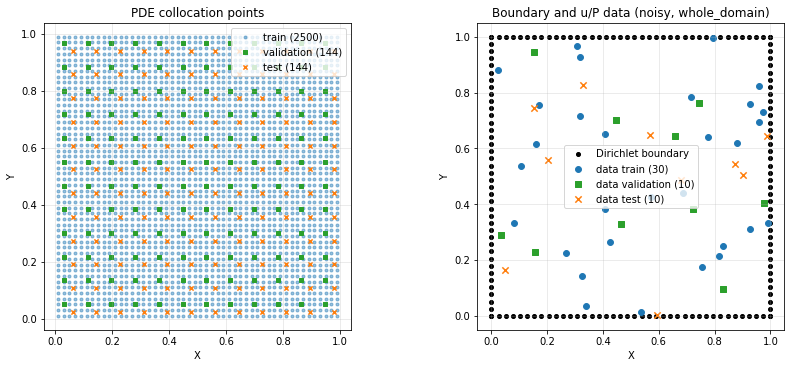

In [10]:
plot_data_split()


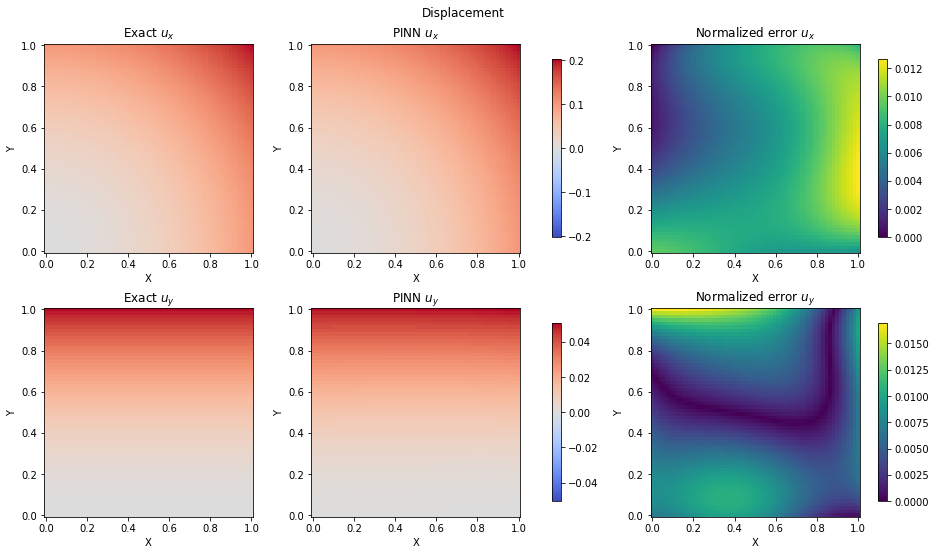

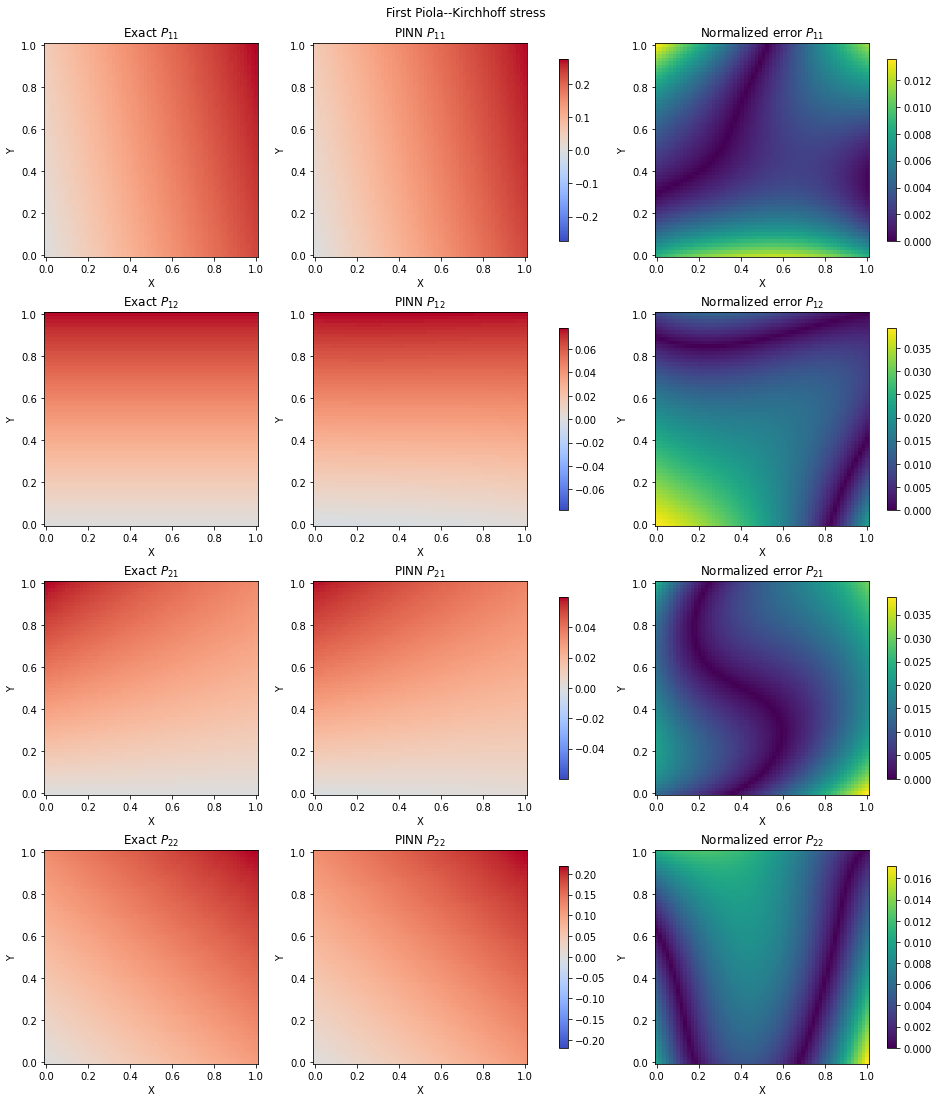

In [11]:
plot_solution()


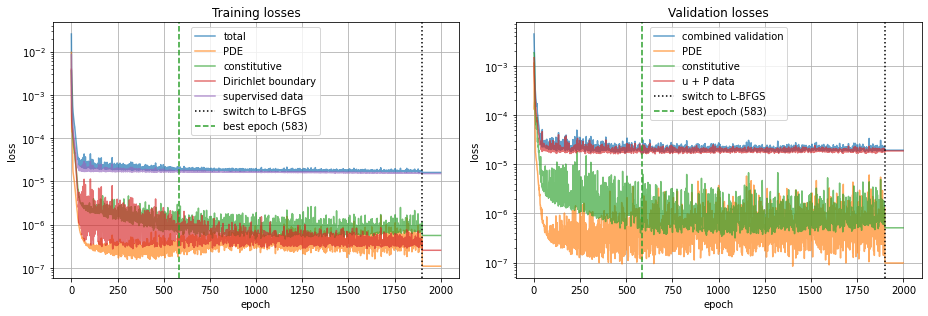

In [12]:
plot_losses()


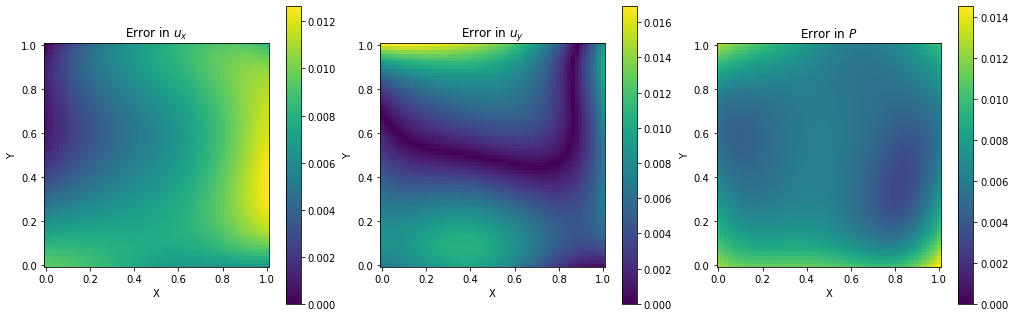

In [13]:
plot_errors()


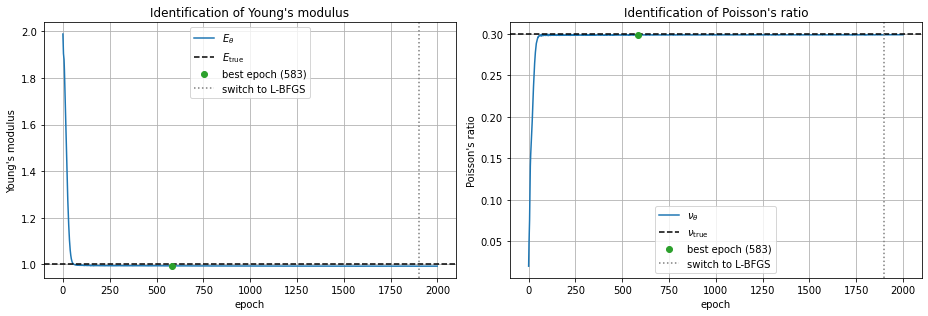

In [14]:
plot_material_parameters()
